In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 4 if torch.cuda.is_available() else 0
print(f'Device: {device}, num_workers: {NUM_WORKERS}')

Device: cpu, num_workers: 0


In [2]:
SEARCH_K      = 10
EVAL_USERS    = 500
SEARCH_EPOCHS = 10
FINAL_EPOCHS  = 20
N_TRIALS      = 40
BATCH_SIZE    = 1024

LAYER_CONFIGS = {
    'small':  [64, 32],
    'medium': [128, 64],
    'large':  [256, 128, 64],
    'xlarge': [256, 128, 64, 32],
}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

SEED = 42
DATA_PATH = '../data/children_products/clildren_product_cleaned.csv'
MIN_INTERACTIONS = 3
SPLIT_QUANTILE = 0.7
K_VALUES = [5, 10, 20]


In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df = df.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df = df.dropna(subset=['Дата'])

if 'Цена' in df.columns:
    df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')

uc = df.groupby('Телефон_new').size()
ic = df.groupby('ID_SKU').size()
df = df[
    df['Телефон_new'].isin(uc[uc >= MIN_INTERACTIONS].index) &
    df['ID_SKU'].isin(ic[ic >= MIN_INTERACTIONS].index)
]
print(f'After filter: users={df["Телефон_new"].nunique():,}, '
      f'items={df["ID_SKU"].nunique():,}, rows={len(df):,}')


After filter: users=35,395, items=22,198, rows=314,493


In [ ]:
interactions = (
    df.groupby(['Телефон_new', 'ID_SKU'])
      .agg(last_date=('Дата', 'max'),
           mean_date=('Дата', 'mean'),
           count=('Дата', 'count'))
      .reset_index()
)

user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_id'] = user_enc.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_enc.fit_transform(interactions['ID_SKU'])

N_USERS = interactions['user_id'].nunique()
N_ITEMS = interactions['item_id'].nunique()
print(f'Unique pairs: {len(interactions):,}, N_USERS={N_USERS:,}, N_ITEMS={N_ITEMS:,}')


Unique pairs: 287,360, N_USERS=35,395, N_ITEMS=22,198


In [6]:
# === SHARED DATA PREP ===
split_ts = interactions['last_date'].quantile(SPLIT_QUANTILE)
print(f'Split timestamp: {split_ts}')

train_df = interactions[interactions['last_date'] <  split_ts].copy()
test_df  = interactions[interactions['last_date'] >= split_ts].copy()

train_users = set(train_df['user_id'].unique())
test_warm = test_df[ test_df['user_id'].isin(train_users)].copy()
test_cold = test_df[~test_df['user_id'].isin(train_users)].copy()

print(f'Train:     {len(train_df):,} pairs / {train_df["user_id"].nunique():,} users')
print(f'Test warm: {len(test_warm):,} pairs / {test_warm["user_id"].nunique():,} users')
print(f'Test cold: {len(test_cold):,} pairs / {test_cold["user_id"].nunique():,} users')

# Sanity: no leakage between train and test (same (user, item) pairs cannot appear in both)
_leak = train_df.merge(test_df, on=['user_id', 'item_id'])
assert len(_leak) == 0, f'Leakage: {len(_leak)} pairs in both train and test'


Split timestamp: 2017-04-12 17:37:00
Train:     201,147 pairs / 28,017 users
Test warm: 42,415 pairs / 7,128 users
Test cold: 43,798 pairs / 7,378 users


In [7]:
def generate_negatives(interactions_df, n_items, n_neg, rng):
    """Генерирует негативные примеры vectorized. Возвращает (users, items) numpy arrays."""
    user_items = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
    pos_users  = interactions_df['user_id'].values
    n_pos = len(pos_users)

    candidates = rng.integers(0, n_items, size=(n_pos, n_neg * 3))

    neg_users, neg_items = [], []
    for i, u in enumerate(pos_users):
        u_set   = user_items.get(int(u), set())
        valid   = [c for c in candidates[i] if c not in u_set][:n_neg]
        # Если кандидатов не хватило — досэмплируем
        while len(valid) < n_neg:
            c = int(rng.integers(0, n_items))
            if c not in u_set:
                valid.append(c)
        neg_users.extend([u] * n_neg)
        neg_items.extend(valid)
    return np.array(neg_users, dtype=np.int64), np.array(neg_items, dtype=np.int64)


class NCFDataset(Dataset):
    """
    Генерирует все негативные примеры один раз при создании.
    Поддерживает веса для временного затухания.
    """
    def __init__(self, interactions_df, n_items, n_neg=4, decay_weights=None, seed=SEED):
        rng = np.random.default_rng(seed)
        t0  = time.time()

        pos_users  = interactions_df['user_id'].values
        pos_items  = interactions_df['item_id'].values
        pos_labels = np.ones(len(pos_users), dtype=np.float32)
        pos_weights = (
            np.asarray(decay_weights, dtype=np.float32)
            if decay_weights is not None
            else np.ones(len(pos_users), dtype=np.float32)
        )

        neg_users, neg_items = generate_negatives(interactions_df, n_items, n_neg, rng)
        neg_labels  = np.zeros(len(neg_users), dtype=np.float32)
        neg_weights = np.ones(len(neg_users),  dtype=np.float32)

        all_users   = np.concatenate([pos_users,   neg_users])
        all_items   = np.concatenate([pos_items,   neg_items])
        all_labels  = np.concatenate([pos_labels,  neg_labels])
        all_weights = np.concatenate([pos_weights, neg_weights])

        # Перемешиваем
        idx = rng.permutation(len(all_users))
        self.users   = torch.from_numpy(all_users[idx])
        self.items   = torch.from_numpy(all_items[idx])
        self.labels  = torch.from_numpy(all_labels[idx])
        self.weights = torch.from_numpy(all_weights[idx])

        print(f'Dataset готов: {len(self):,} примеров ({len(pos_users):,} pos + {len(neg_users):,} neg) за {time.time()-t0:.1f}s')

    def __len__(self):  return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx], self.weights[idx]


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )

In [8]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, n_factors=64, layer_sizes=None, dropout=0.3):
        super().__init__()
        if layer_sizes is None:
            layer_sizes = [256, 128, 64]

        # GMF ветка
        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(n_items, n_factors)

        # MLP ветка
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(n_items, n_factors)

        mlp_layers = []
        in_dim = n_factors * 2
        for out_dim in layer_sizes:
            mlp_layers += [
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = out_dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.fc_out = nn.Linear(n_factors + layer_sizes[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_emb_gmf, self.item_emb_gmf,
                    self.user_emb_mlp, self.item_emb_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)

    def forward(self, users, items):
        gmf_out = self.user_emb_gmf(users) * self.item_emb_gmf(items)
        mlp_in  = torch.cat([self.user_emb_mlp(users), self.item_emb_mlp(items)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        x = torch.cat([gmf_out, mlp_out], dim=-1)
        return torch.sigmoid(self.fc_out(x).squeeze(-1))


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [9]:
def train_model(model, loader, n_epochs, lr=1e-3, verbose=2):
    criterion = nn.BCELoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    model.to(device)
    losses = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        t0 = time.time()

        for users, items, labels, weights in loader:
            users   = users.to(device, non_blocking=True)
            items   = items.to(device, non_blocking=True)
            labels  = labels.to(device, non_blocking=True)
            weights = weights.to(device, non_blocking=True)

            preds = model(users, items)
            loss  = (criterion(preds, labels) * weights).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        losses.append(avg)
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1 or epoch == n_epochs):
            print(f'Epoch {epoch:>3}/{n_epochs}  loss={avg:.4f}  [{time.time()-t0:.1f}s]')

    return losses

In [10]:
def precision_at_k(rec, rel, k):
    hits = len(set(rec[:k]) & set(rel))
    return hits / k if k > 0 else 0.0

def recall_at_k(rec, rel, k):
    if not rel: return 0.0
    return len(set(rec[:k]) & set(rel)) / len(set(rel))

def map_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    score, hits = 0.0, 0
    for i, item in enumerate(rec[:k]):
        if item in rel_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel_set), k)

def ndcg_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    dcg  = sum(1 / np.log2(i + 2) for i, item in enumerate(rec[:k]) if item in rel_set)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(rel_set), k)))
    return dcg / idcg if idcg > 0 else 0.0


@torch.no_grad()
def score_all_items(model, user_ids, n_items, user_batch=32):
    model.eval()
    model.to(device)
    item_t = torch.arange(n_items, device=device)
    all_scores = torch.empty(len(user_ids), n_items)

    for start in range(0, len(user_ids), user_batch):
        batch = user_ids[start:start + user_batch]
        b = len(batch)
        u = torch.tensor(batch, device=device).unsqueeze(1).expand(b, n_items).reshape(-1)
        v = item_t.unsqueeze(0).expand(b, -1).reshape(-1)
        scores = model(u, v).reshape(b, n_items)
        all_scores[start:start + b] = scores.cpu()

    return all_scores


def evaluate_model(model, train_df, test_df, n_items, k_values=K_VALUES,
                   eval_users=None, user_batch=32):
    """
    Быстрая оценка: все скоры считаются батчами на GPU.
    eval_users: список user_id для оценки (None = все тестовые).
    """
    train_hist = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
    test_rel   = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
    train_set  = set(train_df['user_id'].unique())

    if eval_users is None:
        eval_users = [u for u in test_rel if u in train_set]

    t0 = time.time()
    scores = score_all_items(model, eval_users, n_items, user_batch)
    print(f'  Scoring {len(eval_users)} users за {time.time()-t0:.1f}s')

    metrics = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}
    max_k   = max(k_values)

    for i, u in enumerate(eval_users):
        s = scores[i].clone()
        for train_item in train_hist.get(u, set()):
            if train_item < n_items:
                s[train_item] = -1e9

        _, top_idx = torch.topk(s, min(max_k, n_items))
        rec = top_idx.tolist()
        rel = test_rel.get(u, [])

        for k in k_values:
            metrics[k]['precision'].append(precision_at_k(rec, rel, k))
            metrics[k]['recall'].append(recall_at_k(rec, rel, k))
            metrics[k]['map'].append(map_at_k(rec, rel, k))
            metrics[k]['ndcg'].append(ndcg_at_k(rec, rel, k))

    return {
        k: {m: float(np.mean(v)) for m, v in mv.items()}
        for k, mv in metrics.items()
    }


def quick_ndcg(model, train_df, test_df, n_items, eval_users, k=SEARCH_K):
    res = evaluate_model(model, train_df, test_df, n_items,
                         k_values=[k], eval_users=eval_users)
    return res[k]['ndcg']

def eval_warm_cold(model, n_items=None, k_values=None, user_batch=4):
    """Считает метрики отдельно на test_warm и test_cold. Cold ≈ 0 для CF, но фиксируем для отчёта."""
    if n_items is None:
        n_items = N_ITEMS
    if k_values is None:
        k_values = K_VALUES
    warm_users = test_warm['user_id'].unique().tolist()
    cold_users = test_cold['user_id'].unique().tolist()
    warm = evaluate_model(model, train_df, test_warm, n_items,
                          k_values=k_values, eval_users=warm_users, user_batch=user_batch)
    if len(cold_users) > 0:
        cold = evaluate_model(model, train_df, test_cold, n_items,
                              k_values=k_values, eval_users=cold_users, user_batch=user_batch)
    else:
        cold = {k: {'precision': 0.0, 'recall': 0.0, 'map': 0.0, 'ndcg': 0.0} for k in k_values}
    return warm, cold


def print_warm_cold(name, warm, cold, k_values=None):
    if k_values is None:
        k_values = K_VALUES
    print(f'=== {name} ===')
    for cohort, res in [('warm', warm), ('cold', cold)]:
        for k in k_values:
            r = res[k]
            print(f'  [{cohort}] K={k:>2}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  '
                  f'MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')


In [11]:
rng_eval = np.random.default_rng(SEED)
test_users_all = test_warm['user_id'].unique().tolist()
eval_sample = rng_eval.choice(
    test_users_all,
    size=min(EVAL_USERS, len(test_users_all)),
    replace=False,
).tolist()
print(f'Quick-eval sample: {len(eval_sample)} users')

Quick-eval sample: 500 users


In [12]:
print('Подготовка baseline dataset (n_neg=4)...')
baseline_dataset = NCFDataset(train_df, N_ITEMS, n_neg=4)
baseline_loader  = make_loader(baseline_dataset)

baseline_model = NeuMF(N_USERS, N_ITEMS, n_factors=64, layer_sizes=[256, 128, 64])
print(f'Параметров: {count_params(baseline_model):,}')

print('\nОбучение baseline NCF (NeuMF, 20 эпох)...')
t0 = time.time()
baseline_losses = train_model(baseline_model, baseline_loader, n_epochs=FINAL_EPOCHS, lr=1e-3, verbose=2)
print(f'Готово за {time.time()-t0:.0f}s')

Подготовка baseline dataset (n_neg=4)...
Dataset готов: 1,005,735 примеров (201,147 pos + 804,588 neg) за 0.5s
Параметров: 7,447,105

Обучение baseline NCF (NeuMF, 20 эпох)...
Epoch   1/20  loss=0.3985  [19.7s]
Epoch   2/20  loss=0.3510  [19.5s]
Epoch   4/20  loss=0.2891  [19.3s]
Epoch   6/20  loss=0.1874  [19.0s]
Epoch   8/20  loss=0.1242  [19.1s]
Epoch  10/20  loss=0.0952  [19.3s]
Epoch  12/20  loss=0.0799  [19.2s]
Epoch  14/20  loss=0.0695  [19.0s]
Epoch  16/20  loss=0.0637  [18.9s]
Epoch  18/20  loss=0.0592  [18.9s]
Epoch  20/20  loss=0.0562  [18.9s]
Готово за 384s


In [13]:
print('Оценка baseline (warm + cold)...')
baseline_warm, baseline_cold = eval_warm_cold(baseline_model)
print_warm_cold('Baseline PyTorch NCF', baseline_warm, baseline_cold)
baseline_results = baseline_warm 


Оценка baseline (warm + cold)...
  Scoring 7128 users за 77.7s
  Scoring 7378 users за 81.4s
=== Baseline PyTorch NCF ===
  [warm] K= 5: P=0.0129  R=0.0159  MAP=0.0099  NDCG=0.0171
  [warm] K=10: P=0.0119  R=0.0316  MAP=0.0108  NDCG=0.0220
  [warm] K=20: P=0.0107  R=0.0532  MAP=0.0120  NDCG=0.0289
  [cold] K= 5: P=0.0086  R=0.0111  MAP=0.0046  NDCG=0.0095
  [cold] K=10: P=0.0081  R=0.0218  MAP=0.0055  NDCG=0.0134
  [cold] K=20: P=0.0075  R=0.0392  MAP=0.0069  NDCG=0.0196


In [14]:
def make_objective(train_df, test_df, n_users, n_items, eval_users, n_epochs=SEARCH_EPOCHS):
    def objective(trial):
        n_factors  = trial.suggest_int('n_factors', 16, 128)
        lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        layer_key  = trial.suggest_categorical('layers', list(LAYER_CONFIGS.keys()))
        n_neg      = trial.suggest_int('n_neg', 2, 8)
        dropout    = trial.suggest_float('dropout', 0.1, 0.5)

        dataset = NCFDataset(train_df, n_items, n_neg=n_neg)
        loader  = make_loader(dataset)

        model = NeuMF(n_users, n_items,
                      n_factors=n_factors,
                      layer_sizes=LAYER_CONFIGS[layer_key],
                      dropout=dropout)

        train_model(model, loader, n_epochs=n_epochs, lr=lr, verbose=0)
        return quick_ndcg(model, train_df, test_df, n_items, eval_users)

    return objective


print(f'Запуск Optuna: {N_TRIALS} trials, {SEARCH_EPOCHS} эпох каждый...')
t0 = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(
    make_objective(train_df, test_df, N_USERS, N_ITEMS, eval_sample),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print(f'\nГотово за {time.time()-t0:.0f}s')
print(f'Лучший NDCG@{SEARCH_K}: {study.best_value:.4f}')
print(f'Лучшие параметры: {study.best_params}')

Запуск Optuna: 40 trials, 10 эпох каждый...


  0%|          | 0/40 [00:00<?, ?it/s]

Dataset готов: 603,441 примеров (201,147 pos + 402,294 neg) за 0.4s
  Scoring 500 users за 2.1s
Dataset готов: 804,588 примеров (201,147 pos + 603,441 neg) за 0.4s
  Scoring 500 users за 3.7s
Dataset готов: 1,005,735 примеров (201,147 pos + 804,588 neg) за 0.5s
  Scoring 500 users за 6.1s
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 6.7s
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.6s
  Scoring 500 users за 1.3s
Dataset готов: 1,005,735 примеров (201,147 pos + 804,588 neg) за 0.4s
  Scoring 500 users за 2.5s
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 2.3s
Dataset готов: 1,609,176 примеров (201,147 pos + 1,408,029 neg) за 0.5s
  Scoring 500 users за 5.5s
Dataset готов: 1,609,176 примеров (201,147 pos + 1,408,029 neg) за 0.6s
  Scoring 500 users за 6.3s
Dataset готов: 1,005,735 примеров (201,147 pos + 804,588 neg) за 0.4s
  Scoring 500 users за 4.9s
Dataset готов:

,number,NDCG@10,params_n_factors,params_lr,params_layers,params_n_neg,params_dropout
4,4,0.045549,23,0.004094,small,6,0.276061
19,19,0.045193,116,0.002787,medium,7,0.356171
16,16,0.042019,67,0.001533,small,7,0.498116
31,31,0.041579,82,0.001153,medium,7,0.274374
36,36,0.040614,77,0.002210,medium,8,0.466001
22,22,0.040148,89,0.001137,medium,7,0.274798
24,24,0.039355,53,0.003564,small,8,0.331665
27,27,0.038924,21,0.001822,xlarge,7,0.381844
21,21,0.037812,109,0.001570,medium,7,0.368198
6,6,0.037638,77,0.000206,small,6,0.468750


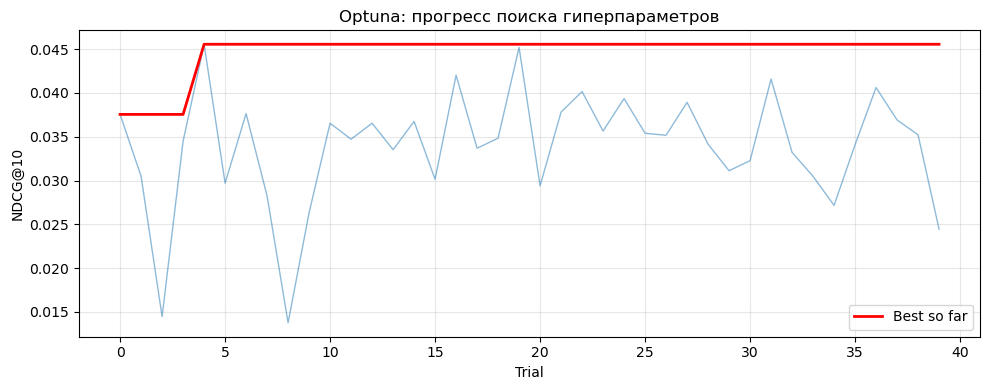

In [15]:
trials_df = study.trials_dataframe()
top10 = trials_df.sort_values('value', ascending=False).head(10)
display(top10[['number', 'value', 'params_n_factors', 'params_lr',
               'params_layers', 'params_n_neg', 'params_dropout']]
        .rename(columns={'value': f'NDCG@{SEARCH_K}'}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_df['number'], trials_df['value'], alpha=0.5, linewidth=1)
ax.plot(trials_df['number'], trials_df['value'].cummax(),
        linewidth=2, color='red', label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel(f'NDCG@{SEARCH_K}')
ax.set_title('Optuna: прогресс поиска гиперпараметров')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
bp = study.best_params
BEST_N_FACTORS = bp['n_factors']
BEST_LR        = bp['lr']
BEST_LAYERS    = LAYER_CONFIGS[bp['layers']]
BEST_N_NEG     = bp['n_neg']
BEST_DROPOUT   = bp['dropout']
print(f'n_factors={BEST_N_FACTORS}, lr={BEST_LR:.2e}, layers={BEST_LAYERS}, '
      f'n_neg={BEST_N_NEG}, dropout={BEST_DROPOUT:.2f}')

print('\nПодготовка dataset с лучшими параметрами...')
best_dataset = NCFDataset(train_df, N_ITEMS, n_neg=BEST_N_NEG)
best_loader  = make_loader(best_dataset)

best_model = NeuMF(N_USERS, N_ITEMS, n_factors=BEST_N_FACTORS,
                   layer_sizes=BEST_LAYERS, dropout=BEST_DROPOUT)
t0 = time.time()
train_model(best_model, best_loader, n_epochs=FINAL_EPOCHS, lr=BEST_LR, verbose=2)
print(f'Готово за {time.time()-t0:.0f}s')

print('\nОценка (warm + cold)...')
best_warm, best_cold = eval_warm_cold(best_model)
print_warm_cold('Optuna best HP', best_warm, best_cold)
best_results = best_warm  # для совместимости

print(f'\n{"K":>4}  {"Метрика":>12}  {"Baseline":>9}  {"BestHP":>9}  {"Δ":>8}')
print('-' * 52)
for k in K_VALUES:
    for m in ['precision', 'recall', 'map', 'ndcg']:
        base = baseline_results[k][m]
        best = best_results[k][m]
        d = best - base
        print(f'{k:>4}  {m+"@"+str(k):>12}  {base:>9.4f}  {best:>9.4f}  {"+" if d>=0 else ""}{d:>7.4f}')


n_factors=23, lr=4.09e-03, layers=[64, 32], n_neg=6, dropout=0.28

Подготовка dataset с лучшими параметрами...
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.6s
Epoch   1/20  loss=0.3280  [17.5s]
Epoch   2/20  loss=0.2975  [17.2s]
Epoch   4/20  loss=0.2745  [17.1s]
Epoch   6/20  loss=0.2582  [17.2s]
Epoch   8/20  loss=0.2435  [17.3s]
Epoch  10/20  loss=0.2318  [17.5s]
Epoch  12/20  loss=0.2228  [17.4s]
Epoch  14/20  loss=0.2159  [17.4s]
Epoch  16/20  loss=0.2106  [17.7s]
Epoch  18/20  loss=0.2063  [17.4s]
Epoch  20/20  loss=0.2023  [17.5s]
Готово за 348s

Оценка (warm + cold)...
  Scoring 7128 users за 20.7s
  Scoring 7378 users за 21.7s
=== Optuna best HP ===
  [warm] K= 5: P=0.0272  R=0.0398  MAP=0.0261  NDCG=0.0406
  [warm] K=10: P=0.0223  R=0.0587  MAP=0.0262  NDCG=0.0463
  [warm] K=20: P=0.0184  R=0.0851  MAP=0.0277  NDCG=0.0550
  [cold] K= 5: P=0.0124  R=0.0161  MAP=0.0106  NDCG=0.0172
  [cold] K=10: P=0.0109  R=0.0249  MAP=0.0110  NDCG=0.0206
  [cold] K=20:

In [17]:
days_before_split = (
    split_ts - train_df['mean_date']
).dt.total_seconds().values / 86400
days_before_split = np.clip(days_before_split, 0, None)

DECAY_LAMBDAS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
decay_scores  = []

for lam in DECAY_LAMBDAS:
    t0 = time.time()
    weights = np.exp(-lam * days_before_split).clip(1e-6)

    dataset = NCFDataset(train_df, N_ITEMS, n_neg=BEST_N_NEG, decay_weights=weights)
    loader  = make_loader(dataset)

    model = NeuMF(N_USERS, N_ITEMS, n_factors=BEST_N_FACTORS,
                  layer_sizes=BEST_LAYERS, dropout=BEST_DROPOUT)
    train_model(model, loader, n_epochs=SEARCH_EPOCHS, lr=BEST_LR, verbose=0)

    score = quick_ndcg(model, train_df, test_df, N_ITEMS, eval_sample)
    decay_scores.append(score)
    print(f'  λ={lam:.3f}  NDCG@{SEARCH_K}={score:.4f}  ({time.time()-t0:.0f}s)')

BEST_LAMBDA = DECAY_LAMBDAS[int(np.argmax(decay_scores))]
print(f'\nЛучшая λ = {BEST_LAMBDA}')

Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 1.5s
  λ=0.001  NDCG@10=0.0391  (182s)
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.6s
  Scoring 500 users за 1.3s
  λ=0.005  NDCG@10=0.0418  (184s)
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 1.3s
  λ=0.010  NDCG@10=0.0395  (177s)
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 1.3s
  λ=0.020  NDCG@10=0.0395  (180s)
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.6s
  Scoring 500 users за 1.3s
  λ=0.050  NDCG@10=0.0401  (182s)
Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.5s
  Scoring 500 users за 1.3s
  λ=0.100  NDCG@10=0.0328  (186s)

Лучшая λ = 0.005


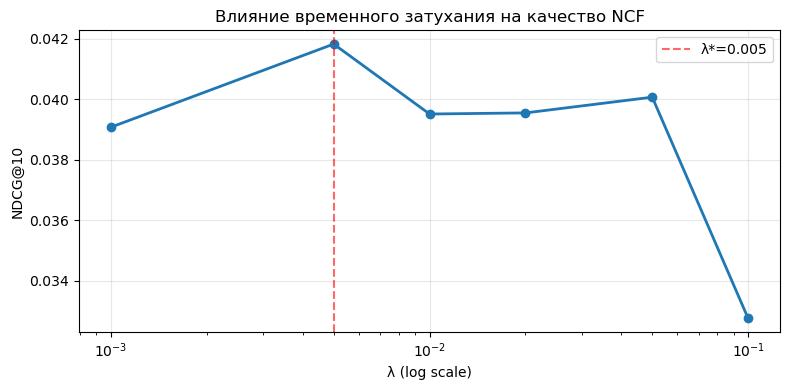

Dataset готов: 1,408,029 примеров (201,147 pos + 1,206,882 neg) за 0.6s
Epoch   1/20  loss=0.3068  [17.1s]
Epoch   2/20  loss=0.2779  [17.3s]
Epoch   4/20  loss=0.2582  [17.1s]
Epoch   6/20  loss=0.2441  [17.0s]
Epoch   8/20  loss=0.2308  [17.2s]
Epoch  10/20  loss=0.2206  [17.3s]
Epoch  12/20  loss=0.2138  [17.8s]
Epoch  14/20  loss=0.2087  [17.4s]
Epoch  16/20  loss=0.2044  [17.3s]
Epoch  18/20  loss=0.2002  [17.2s]
Epoch  20/20  loss=0.1962  [17.3s]
Готово за 346s

Оценка (warm + cold)...
  Scoring 7128 users за 20.2s
  Scoring 7378 users за 20.8s
=== Time decay ===
  [warm] K= 5: P=0.0248  R=0.0348  MAP=0.0228  NDCG=0.0362
  [warm] K=10: P=0.0206  R=0.0539  MAP=0.0232  NDCG=0.0419
  [warm] K=20: P=0.0174  R=0.0820  MAP=0.0248  NDCG=0.0512
  [cold] K= 5: P=0.0101  R=0.0140  MAP=0.0080  NDCG=0.0139
  [cold] K=10: P=0.0096  R=0.0250  MAP=0.0088  NDCG=0.0180
  [cold] K=20: P=0.0081  R=0.0379  MAP=0.0098  NDCG=0.0229


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(DECAY_LAMBDAS, decay_scores, marker='o', linewidth=2)
ax.axvline(BEST_LAMBDA, color='red', linestyle='--', alpha=0.6, label=f'λ*={BEST_LAMBDA}')
ax.set_xscale('log')
ax.set_xlabel('λ (log scale)'); ax.set_ylabel(f'NDCG@{SEARCH_K}')
ax.set_title('Влияние временного затухания на качество NCF')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Финальное обучение с лучшей λ
best_weights = np.exp(-BEST_LAMBDA * days_before_split).clip(1e-6)
decay_dataset = NCFDataset(train_df, N_ITEMS, n_neg=BEST_N_NEG, decay_weights=best_weights)
decay_loader  = make_loader(decay_dataset)

decay_model = NeuMF(N_USERS, N_ITEMS, n_factors=BEST_N_FACTORS,
                    layer_sizes=BEST_LAYERS, dropout=BEST_DROPOUT)
t0 = time.time()
train_model(decay_model, decay_loader, n_epochs=FINAL_EPOCHS, lr=BEST_LR, verbose=2)
print(f'Готово за {time.time()-t0:.0f}s')

print('\nОценка (warm + cold)...')
decay_warm, decay_cold = eval_warm_cold(decay_model)
print_warm_cold('Time decay', decay_warm, decay_cold)
decay_results = decay_warm  # для совместимости


               Вариант  Cohort    NDCG@10     MAP@10    ΔNDCG@10
----------------------------------------------------------------------
           baseline_pt    warm     0.0220     0.0108  +   0.0000
       best_hparams_pt    warm     0.0463     0.0262  +   0.0243
         time_decay_pt    warm     0.0419     0.0232  +   0.0199
           baseline_pt    cold     0.0134     0.0055           —
       best_hparams_pt    cold     0.0206     0.0110           —
         time_decay_pt    cold     0.0180     0.0088           —


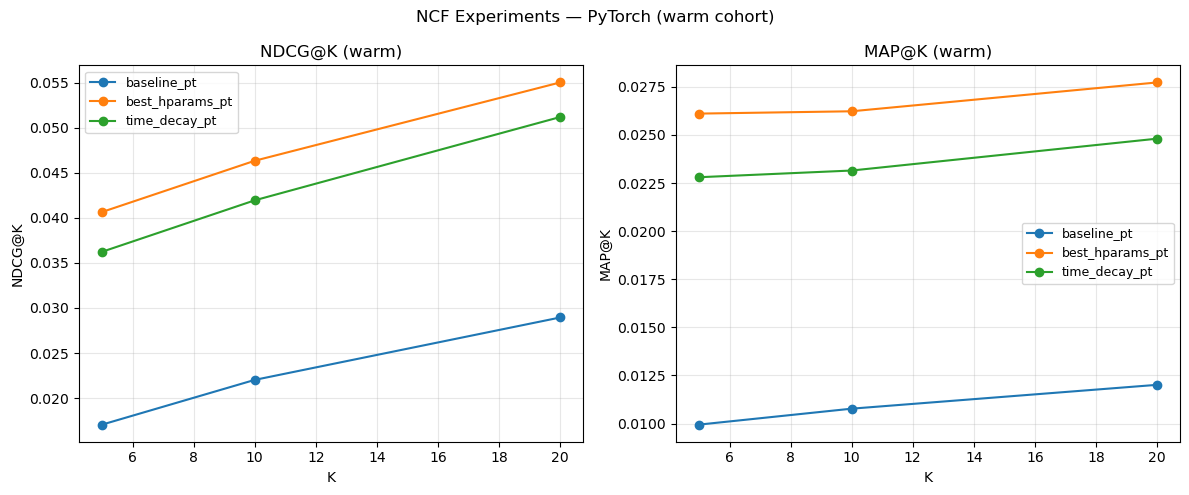

In [19]:
all_warm = {
    'baseline_pt':     baseline_warm,
    'best_hparams_pt': best_warm,
    'time_decay_pt':   decay_warm,
}
all_cold = {
    'baseline_pt':     baseline_cold,
    'best_hparams_pt': best_cold,
    'time_decay_pt':   decay_cold,
}

print(f'{"Вариант":>22}  {"Cohort":>6}  {"NDCG@10":>9}  {"MAP@10":>9}  {"ΔNDCG@10":>10}')
print('-' * 70)
ref = baseline_warm
for cohort, table in [('warm', all_warm), ('cold', all_cold)]:
    for name, res in table.items():
        ndcg = res[10]['ndcg']
        mmap = res[10]['map']
        if cohort == 'warm':
            d = ndcg - ref[10]['ndcg']
            d_str = f'{"+" if d>=0 else ""}{d:>9.4f}'
        else:
            d_str = '—'
        print(f'{name:>22}  {cohort:>6}  {ndcg:>9.4f}  {mmap:>9.4f}  {d_str:>10}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = sns.color_palette('tab10', len(all_warm))
for ax, metric in zip(axes, ['ndcg', 'map']):
    for (name, res), color in zip(all_warm.items(), colors):
        y = [res[k][metric] for k in K_VALUES]
        ax.plot(K_VALUES, y, marker='o', linewidth=1.5, label=name, color=color)
    ax.set_xlabel('K'); ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K (warm)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('NCF Experiments — PyTorch (warm cohort)', fontsize=12)
plt.tight_layout(); plt.show()


In [20]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    _utils = _cand / 'source' / 'utils'
    if _utils.exists():
        sys.path.insert(0, str(_utils))
        break
import importlib, timing as _t
importlib.reload(_t)
from timing import benchmark_user_latency, benchmark_batch_latency, save_benchmark, detect_hardware

rng = np.random.RandomState(SEED)
test_users_arr = test_warm['user_id'].unique()
sample_size = min(2000, len(test_users_arr))
bench_users = rng.choice(test_users_arr, size=sample_size, replace=False).tolist()

# Train history for filtering already-liked items
train_hist = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

best_model.eval()
best_model.to(device)
_use_cuda = (device.type == 'cuda')
print(f'Benchmarking on {len(bench_users)} users (device={device}, sync_cuda={_use_cuda})')

DATASET_META = {
    'n_users': int(N_USERS), 'n_items': int(N_ITEMS),
    'n_train_pairs': int(len(train_df)),
}
NCF_EXTRA_BASE = {
    'library': 'torch_custom_neumf',
    'n_factors': BEST_N_FACTORS, 'layers': BEST_LAYERS,
    'n_neg': BEST_N_NEG, 'dropout': BEST_DROPOUT,
    'final_epochs': FINAL_EPOCHS,
    'sync_cuda': _use_cuda,
}

Benchmarking on 2000 users (device=cpu, sync_cuda=False)


In [ ]:
import torch

_item_t_full = torch.arange(N_ITEMS, device=device)

@torch.no_grad()
def ncf_single_recommend(uid, k=10):
    u = torch.full((N_ITEMS,), int(uid), device=device, dtype=torch.long)
    scores = best_model(u, _item_t_full)
    bought = train_hist.get(uid, set())
    if bought:
        scores[torch.tensor(list(bought), device=device, dtype=torch.long)] = float('-inf')
    topk = torch.topk(scores, k).indices.cpu().numpy()
    return topk

stats_single = benchmark_user_latency(
    ncf_single_recommend, bench_users, warmup=100, k=10, sync_cuda=_use_cuda,
    label='NCF-PyTorch single'
)
print(f"NCF single ({device}): mean={stats_single['mean_ms']:.3f}ms  p50={stats_single['p50_ms']:.3f}  p95={stats_single['p95_ms']:.3f}")

hw = detect_hardware(prefer='gpu') if _use_cuda else detect_hardware(prefer='cpu')
save_benchmark(
    stats_single, model_name='NCF-PyTorch', stage='single',
    hardware=hw, dataset_meta=DATASET_META,
    extra={**NCF_EXTRA_BASE, 'mode_desc': 'one user, all items, top-K'},
    notebook='experiments/ncf_experiments_pytorch.ipynb', n_items=N_ITEMS,
)

NCF single (cpu): mean=3.644ms  p50=3.632  p95=4.379


'NCF-PyTorch_single_20260509T222928'

In [ ]:

USER_BATCH = 32

@torch.no_grad()
def ncf_batch_recommend(user_ids_chunk):
    b = len(user_ids_chunk)
    u = torch.tensor(user_ids_chunk, device=device, dtype=torch.long).unsqueeze(1).expand(b, N_ITEMS).reshape(-1)
    v = _item_t_full.unsqueeze(0).expand(b, -1).reshape(-1)
    scores = best_model(u, v).reshape(b, N_ITEMS)
    return scores.cpu()

stats_batch = benchmark_batch_latency(
    ncf_batch_recommend, bench_users, batch_size=USER_BATCH, warmup_batches=2,
    k=10, sync_cuda=_use_cuda, label='NCF-PyTorch batch32'
)
print(f"NCF batch{USER_BATCH} ({device}) amortized: mean={stats_batch['mean_ms']:.3f}ms  p50={stats_batch['p50_ms']:.3f}  p95={stats_batch['p95_ms']:.3f}")

save_benchmark(
    stats_batch, model_name='NCF-PyTorch', stage='single',
    hardware=hw, dataset_meta=DATASET_META,
    extra={**NCF_EXTRA_BASE, 'user_batch': USER_BATCH,
           'mode_desc': 'batched scoring, all items, amortized per-user'},
    notebook='experiments/ncf_experiments_pytorch.ipynb', n_items=N_ITEMS,
)

NCF batch32 (cpu) amortized: mean=2.628ms  p50=2.623  p95=2.699


'NCF-PyTorch_single_20260509T222933'